# 03 - Tarea 3: Transfer Learning con ResNet-18
ResNet-18 preentrenada en ImageNet (torchvision), entrada 224×224 con estadísticas de ImageNet. Tres estrategias × 3 semillas (42, 43, 44), Adam, batch 64, 10 épocas:
- **Feature extraction**: solo `fc` entrenable (lr 1e-3).
- **Fine-tuning parcial**: se congelan conv1/bn1/layer1/layer2; se entrenan layer3, layer4 y fc (lr 1e-4).
- **Fine-tuning total**: todo entrenable con lr muy pequeño (1e-5).

Las capas BatchNorm congeladas se mantienen en modo eval. Se compara con el mejor modelo desde cero (VGG-11+BN, Tarea 1).

In [1]:
import sys, json; sys.path.append('../src')
import pandas as pd  # importar pandas ANTES que torch: evita un crash del kernel en Windows
import numpy as np, torch, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix
from utils import get_loaders, FIG_DIR, ROOT, CLASSES, MEAN_IMAGENET, STD_IMAGENET
from models import TransferResNet18, count_trainable
from train import run_experiment

RES_DIR = ROOT/'results'; CKPT_DIR = RES_DIR/'checkpoints'; CKPT_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device, torch.cuda.get_device_name(0) if device.type == 'cuda' else '')
EPOCHS, BS, SEEDS = 10, 64, [42, 43, 44]
STRATS = {'feature_extraction': 1e-3, 'partial': 1e-4, 'full': 1e-5}
train_loader, val_loader, test_loader = get_loaders(img_size=224, batch_size=BS,
                                                    mean=MEAN_IMAGENET, std=STD_IMAGENET)

cuda NVIDIA GeForce RTX 4050 Laptop GPU


## Entrenamiento: 3 estrategias × 3 semillas

In [2]:
runs = {s: [] for s in STRATS}
for s, lr in STRATS.items():
    for seed in SEEDS:
        r = run_experiment(lambda: TransferResNet18(s), f'resnet18_{s}', train_loader, val_loader, test_loader,
                           EPOCHS, lr, device, seed, CKPT_DIR)
        runs[s].append(r)
        print(f"{s:19s} seed {seed} | best val {max(r['hist']['val_acc']):.4f} | test {r['test_acc']:.4f}")
trainable = {s: count_trainable(TransferResNet18(s, pretrained=False)) for s in STRATS}

feature_extraction  seed 42 | best val 0.6526 | test 0.4029


feature_extraction  seed 43 | best val 0.6526 | test 0.4294


feature_extraction  seed 44 | best val 0.6345 | test 0.4343


partial             seed 42 | best val 1.0000 | test 0.8315


partial             seed 43 | best val 0.9993 | test 0.8299


partial             seed 44 | best val 1.0000 | test 0.8134


full                seed 42 | best val 1.0000 | test 0.8561


full                seed 43 | best val 1.0000 | test 0.8589


full                seed 44 | best val 1.0000 | test 0.8661


## Tabla resumen y comparación con el mejor modelo desde cero

In [3]:
def first_epoch_over(h, thr=0.8):
    return next((i+1 for i, a in enumerate(h['val_acc']) if a >= thr), None)

ms = lambda v, d=4: f"{np.mean(v):.{d}f} ± {np.std(v):.{d}f}"
rows = []
for s, rs in runs.items():
    e = [first_epoch_over(r['hist']) for r in rs]; ok = [x for x in e if x is not None]
    rows.append({'Modelo': f'ResNet-18 {s}', 'Parámetros totales': rs[0]['params'], 'Entrenables': trainable[s],
                 'LR': f'{STRATS[s]:g}', 'Tiempo/época (s)': ms([np.mean(r['hist']['epoch_time'][1:]) for r in rs], 1),
                 'Mejor val acc': ms([max(r['hist']['val_acc']) for r in rs]),
                 'Test acc': ms([r['test_acc'] for r in rs]),
                 'Épocas a 80% val': f"{np.mean(ok):.1f} ({len(ok)}/3)" if ok else '-'})
# referencia desde cero (Tarea 1)
t1 = json.load(open(RES_DIR/'t1_resultados.json'))['vgg11_bn']
e = [first_epoch_over(r['hist']) for r in t1]
rows.append({'Modelo': 'VGG-11+BN desde cero (T1)', 'Parámetros totales': t1[0]['params'], 'Entrenables': t1[0]['params'],
             'LR': '0.001', 'Tiempo/época (s)': ms([np.mean(r['hist']['epoch_time'][1:]) for r in t1], 1),
             'Mejor val acc': ms([max(r['hist']['val_acc']) for r in t1]), 'Test acc': ms([r['test_acc'] for r in t1]),
             'Épocas a 80% val': f"{np.mean(e):.1f} (3/3)"})
summary = pd.DataFrame(rows); summary.to_csv(RES_DIR/'t3_resumen.csv', index=False)
json.dump({s: [dict(seed=r['seed'], params=r['params'], hist=r['hist'], test_acc=r['test_acc'],
                    y_true=r['y_true'], y_pred=r['y_pred']) for r in rs] for s, rs in runs.items()},
          open(RES_DIR/'t3_resultados.json', 'w'))
summary

,Modelo,Parámetros totales,Entrenables,LR,Tiempo/época (s),Mejor val acc,Test acc,Épocas a 80% val
0,ResNet-18 feature_extraction,11178564,2052,0.001,17.2 ± 0.7,0.6466 ± 0.0085,0.4222 ± 0.0138,-
1,ResNet-18 partial,11178564,10495492,0.0001,25.3 ± 0.8,0.9998 ± 0.0003,0.8250 ± 0.0082,1.0 (3/3)
2,ResNet-18 full,11178564,11178564,1e-05,37.8 ± 0.4,1.0000 ± 0.0000,0.8603 ± 0.0042,1.0 (3/3)
3,VGG-11+BN desde cero (T1),3097124,3097124,0.001,3.8 ± 0.1,0.9819 ± 0.0038,0.8514 ± 0.0164,9.0 (3/3)


In [4]:
pd.DataFrame([{'Estrategia': s, 'Semilla': r['seed'], 'Mejor val acc': round(max(r['hist']['val_acc']), 4),
               'Test acc': round(r['test_acc'], 4)} for s, rs in runs.items() for r in rs]).pivot(
    index='Estrategia', columns='Semilla', values=['Mejor val acc', 'Test acc'])

Mejor val acc                 Test acc                
Semilla                       42      43      44       42      43      44
Estrategia                                                               
feature_extraction        0.6526  0.6526  0.6345   0.4029  0.4294  0.4343
full                      1.0000  1.0000  1.0000   0.8561  0.8589  0.8661
partial                   1.0000  0.9993  1.0000   0.8315  0.8299  0.8134

## Curvas de entrenamiento (media ± desviación entre semillas)

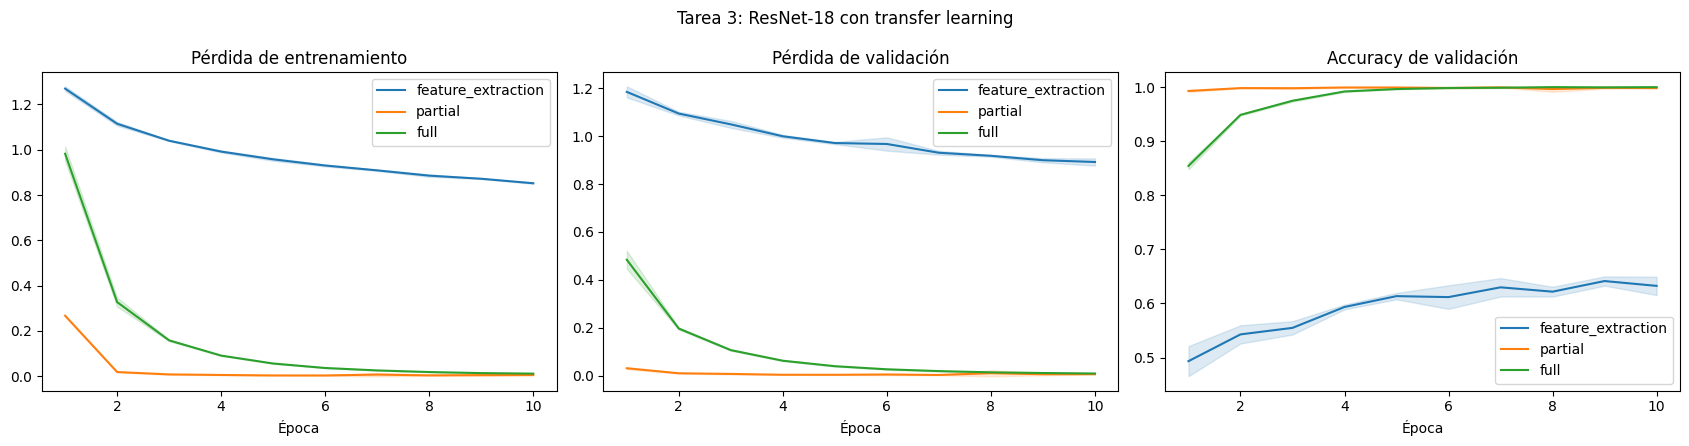

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(17, 4.5))
cols = {'feature_extraction': 'tab:blue', 'partial': 'tab:orange', 'full': 'tab:green'}
ep = np.arange(1, EPOCHS+1)
for ax, (key, ttl) in zip(axs, [('train_loss', 'Pérdida de entrenamiento'), ('val_loss', 'Pérdida de validación'),
                                ('val_acc', 'Accuracy de validación')]):
    for s, rs in runs.items():
        a = np.array([r['hist'][key] for r in rs]); m, sd = a.mean(0), a.std(0)
        ax.plot(ep, m, color=cols[s], label=s); ax.fill_between(ep, m-sd, m+sd, color=cols[s], alpha=.15)
    ax.set_title(ttl); ax.set_xlabel('Época'); ax.legend()
fig.suptitle('Tarea 3: ResNet-18 con transfer learning'); plt.tight_layout()
plt.savefig(FIG_DIR/'t3_curvas.png', dpi=150); plt.show()

## Matriz de confusión del mejor modelo en TEST

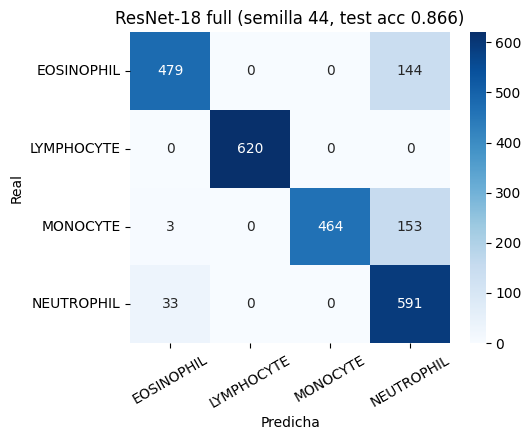

full 44 {'EOSINOPHIL': 0.769, 'LYMPHOCYTE': 1.0, 'MONOCYTE': 0.748, 'NEUTROPHIL': 0.947}


In [6]:
best_s = max(runs, key=lambda s: np.mean([r['test_acc'] for r in runs[s]]))
r = max(runs[best_s], key=lambda r: r['test_acc'])
cm = confusion_matrix(r['y_true'], r['y_pred'])
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f"ResNet-18 {best_s} (semilla {r['seed']}, test acc {r['test_acc']:.3f})")
plt.xlabel('Predicha'); plt.ylabel('Real'); plt.xticks(rotation=30); plt.tight_layout()
plt.savefig(FIG_DIR/'t3_confusion_mejor.png', dpi=150); plt.show()
print(best_s, r['seed'], pd.Series(np.diag(confusion_matrix(r['y_true'], r['y_pred'], normalize='true')).round(3), index=CLASSES).to_dict())